### Import required modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import numpy as np

sns.set_style("whitegrid")

## Load all dataset using python

In [2]:
train_df = pd.read_csv("./datasets/train.csv")
val_df = pd.read_csv("./datasets/val.csv")
test_df = pd.read_csv("./datasets/test.csv")

train_df.head()

,Year,dengue_total,Location,Month,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation,daily_rain_density,average_humidity,avg_soil_moisture,avg_soil_temperature,avg_snowfall,avg_precipitation
0,2024,0,KALIKOT,May,10.223880,19.783870,88.951584,0.418761,10.755308,0.000000,19.783870,high,extreme,high,low,none,high
1,2022,0,PARSA,Feb,30.428612,6.673333,62.701965,0.234122,28.814114,0.000000,6.673333,moderate,high,moderate,high,none,moderate
2,2024,19,SALYAN,Sep,10.010685,0.100000,70.479485,0.319492,11.226091,0.000000,0.100000,low,high,high,low,none,low
3,2022,1,BAJHANG,Jan,-6.802581,0.000000,34.566444,0.366226,-1.123817,0.388387,0.551613,no,low,high,low,light,low
4,2022,0,KALIKOT,May,10.058961,13.132258,89.504610,0.415793,10.209129,0.000000,13.132258,high,extreme,high,low,none,high


## Use only selected features for linear regression

In [3]:
selected_columns = [
    "Year",
    "dengue_total",
    "Location",
    "Month",
    "monthly_avg_temperature",
    "avg_daily_rain",
    "avg_daily_humidity",
    "avg_daily_soil_moisture",
    "avg_daily_soil_temperature",
    "avg_daily_snowfall",
    "avg_daily_precipitation"
]

train = train_df[selected_columns]
val = val_df[selected_columns]
test = test_df[selected_columns]

all_locations = sorted(pd.concat([train["Location"], val["Location"], test["Location"]]).unique())
all_months = sorted(pd.concat([train["Month"], val["Month"], test["Month"]]).unique())

train_loc = pd.get_dummies(train["Location"].astype(pd.CategoricalDtype(all_locations)), dtype=int)
train_month = pd.get_dummies(train["Month"].astype(pd.CategoricalDtype(all_months)), dtype=int)

val_loc = pd.get_dummies(val["Location"].astype(pd.CategoricalDtype(all_locations)), dtype=int)
val_month = pd.get_dummies(val["Month"].astype(pd.CategoricalDtype(all_months)), dtype=int)

test_loc = pd.get_dummies(test["Location"].astype(pd.CategoricalDtype(all_locations)), dtype=int)
test_month = pd.get_dummies(test["Month"].astype(pd.CategoricalDtype(all_months)), dtype=int)

train = pd.concat([train.drop(columns=["Month", "Location"]), train_loc, train_month], axis=1)
val = pd.concat([val.drop(columns=["Month", "Location"]), val_loc, val_month], axis=1)
test = pd.concat([test.drop(columns=["Month", "Location"]), test_loc, test_month], axis=1)

train.head()

,Year,dengue_total,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation,ACHHAM,...,Dec,Feb,Jan,Jul,Jun,Mar,May,Nov,Oct,Sep
0,2024,0,10.223880,19.783870,88.951584,0.418761,10.755308,0.000000,19.783870,0,...,0,0,0,0,0,0,1,0,0,0
1,2022,0,30.428612,6.673333,62.701965,0.234122,28.814114,0.000000,6.673333,0,...,0,1,0,0,0,0,0,0,0,0
2,2024,19,10.010685,0.100000,70.479485,0.319492,11.226091,0.000000,0.100000,0,...,0,0,0,0,0,0,0,0,0,1
3,2022,1,-6.802581,0.000000,34.566444,0.366226,-1.123817,0.388387,0.551613,0,...,0,0,1,0,0,0,0,0,0,0
4,2022,0,10.058961,13.132258,89.504610,0.415793,10.209129,0.000000,13.132258,0,...,0,0,0,0,0,0,1,0,0,0


# Extract X and Y from data

### Normalize and prepare


In [4]:
def normalize_train(x):
    mean = np.nanmean(x, axis=0)
    std = np.nanstd(x, axis=0)
    std = np.where(std == 0, 1, std)
    x_norm = (x - mean) / std
    x_norm = np.nan_to_num(x_norm)
    return x_norm, mean, std

def normalize_pred(x, mean, std):
    std = np.where(std == 0, 1, std)
    x_norm = (x - mean) / std
    return np.nan_to_num(x_norm)


Training set

In [5]:
x_train= train.drop(columns=["dengue_total"])
# all the features
features = x_train.columns.to_list()

x_train, x_mean, x_std = normalize_train(x_train.to_numpy())
y_train, y_mean, y_std = normalize_train(train["dengue_total"].to_numpy())

print("Columns of features:")
print(features)

print(f"Shape of x: {x_train.shape}")

Columns of features:
['Year', 'monthly_avg_temperature', 'avg_daily_rain', 'avg_daily_humidity', 'avg_daily_soil_moisture', 'avg_daily_soil_temperature', 'avg_daily_snowfall', 'avg_daily_precipitation', 'ACHHAM', 'ARGHAKHANCHI', 'BAGLUNG', 'BAITADI', 'BAJHANG', 'BAJURA', 'BANKE', 'BARA', 'BARDIYA', 'BHAKTAPUR', 'BHOJPUR', 'DADELDHURA', 'DAILEKH', 'DANG', 'DARCHULA', 'DHADING', 'DHANKUTA', 'DHANUSA', 'DOLAKHA', 'DOLPA', 'DOTI', 'GORKHA', 'GULMI', 'HUMLA', 'ILAM', 'JAJARKOT', 'JHAPA', 'JUMLA', 'KAILALI', 'KALIKOT', 'KANCHANPUR', 'KASKI', 'KATHMANDU', 'KHOTANG', 'LALITPUR', 'LAMJUNG', 'MAHOTTARI', 'MAKWANPUR', 'MANANG', 'MORANG', 'MUGU', 'MUSTANG', 'MYAGDI', 'NUWAKOT', 'OKHALDHUNGA', 'PALPA', 'PANCHTHAR', 'PARBAT', 'PARSA', 'PYUTHAN', 'RAMECHHAP', 'RASUWA', 'RAUTAHAT', 'ROLPA', 'RUPANDEHI', 'SALYAN', 'SANKHUWASABHA', 'SAPTARI', 'SARLAHI', 'SINDHULI', 'SINDHUPALCHOK', 'SIRAHA', 'SOLUKHUMBU', 'SUNSARI', 'SURKHET', 'SYANGJA', 'TANAHU', 'TAPLEJUNG', 'UDAYAPUR', 'Apr', 'Aug', 'Dec', 'Feb', 'Ja

Validation and Test set

In [6]:
# Validation Set
x_val = normalize_pred(val.drop(columns=["dengue_total"]).to_numpy(), x_mean, x_std)
y_val = normalize_pred(val["dengue_total"].to_numpy(), y_mean, y_std)

# Testing Set
x_test = normalize_pred(test.drop(columns=["dengue_total"]).to_numpy(), x_mean, x_std)
y_test = normalize_pred(test["dengue_total"].to_numpy(),y_mean, y_std)

print(f"Validation and test sets are ready to use!")

Validation and test sets are ready to use!


# LinearRegression Architecture

In [7]:
class LinearRegression:
    def __init__(self, shape, lr=0.01):
        self.w = np.random.randn(shape)
        self.b = 0.0
        self.lr = lr

    def fit(self, x, y):
        y_pred = x.dot(self.w) + self.b
        error = y_pred - y

        grad_w = x.T.dot(error) / len(y)
        grad_b = np.mean(error)

        self.w -= self.lr * grad_w
        self.b -= self.lr * grad_b

        return np.mean(error ** 2), r2_score(y, y_pred)

    def predict(self, x):
        return x.dot(self.w) + self.b


# Training Linear Model in 400 Epochs

In [8]:
model = LinearRegression(x_train.shape[1], 0.05)
epochs = [i+1 for i in range(400)]

train_losses = []
val_losses = []

train_r2 = []
val_r2 = []

In [9]:
for epoch in range(1, 401):
    train_loss, r2_t = model.fit(x=x_train, y=y_train)
    train_losses.append(train_loss)
    train_r2.append(r2_t)

    preds = model.predict(x_val)
    
    val_loss = np.mean((preds - y_val) ** 2)
    r2_v = r2_score(y_val, preds)
    val_r2.append(r2_v)
    
    val_losses.append(val_loss)

    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")


Epoch 20: Train Loss=11.1130, Val Loss=10.2212
Epoch 40: Train Loss=2.2041, Val Loss=2.3408
Epoch 60: Train Loss=1.0849, Val Loss=1.3497
Epoch 80: Train Loss=0.9256, Val Loss=1.2072
Epoch 100: Train Loss=0.8942, Val Loss=1.1779
Epoch 120: Train Loss=0.8841, Val Loss=1.1677
Epoch 140: Train Loss=0.8793, Val Loss=1.1625
Epoch 160: Train Loss=0.8766, Val Loss=1.1594
Epoch 180: Train Loss=0.8749, Val Loss=1.1575
Epoch 200: Train Loss=0.8738, Val Loss=1.1562
Epoch 220: Train Loss=0.8731, Val Loss=1.1553
Epoch 240: Train Loss=0.8726, Val Loss=1.1546
Epoch 260: Train Loss=0.8722, Val Loss=1.1541
Epoch 280: Train Loss=0.8719, Val Loss=1.1537
Epoch 300: Train Loss=0.8717, Val Loss=1.1534
Epoch 320: Train Loss=0.8716, Val Loss=1.1532
Epoch 340: Train Loss=0.8714, Val Loss=1.1530
Epoch 360: Train Loss=0.8713, Val Loss=1.1528
Epoch 380: Train Loss=0.8712, Val Loss=1.1527
Epoch 400: Train Loss=0.8711, Val Loss=1.1526


### Visualize Loss Drop comparing training and validation set

In [10]:
metric = pd.DataFrame({
    "epoch":epochs,
    
    "train_loss":train_losses,
    "val_loss":val_losses,
    
    "val_r2":val_r2,
    "train_r2":train_r2
    
})

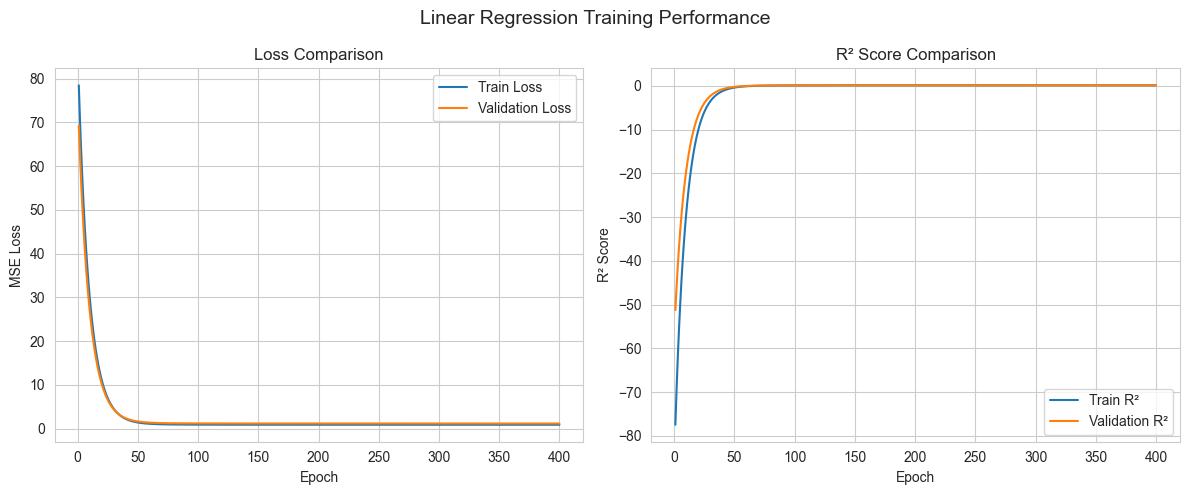

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle("Linear Regression Training Performance", fontsize=14)

# Loss plot
sns.lineplot(
    data=metric,
    x="epoch",
    y="train_loss",
    label="Train Loss",
    ax=axes[0]
)

sns.lineplot(
    data=metric,
    x="epoch",
    y="val_loss",
    label="Validation Loss",
    ax=axes[0]
)

axes[0].set_title("Loss Comparison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()


# R2 plot
sns.lineplot(
    data=metric,
    x="epoch",
    y="train_r2",
    label="Train R²",
    ax=axes[1]
)

sns.lineplot(
    data=metric,
    x="epoch",
    y="val_r2",
    label="Validation R²",
    ax=axes[1]
)

axes[1].set_title("R² Score Comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("R² Score")
axes[1].legend()


plt.tight_layout()
plt.savefig("./resources/Dengu_Risk_Linear_Regression.png", dpi=200)
plt.show()

In the loss chart, one sees a fast and consistent convergence pattern, with the MSE falling drastically from roughly 78 down to nearly 0 within ~50 epochs, and the lines for both train and validation being perfectly correlated all the way with no divergence – hence, there is no overfitting and the training procedure is stable.

However, in the R² plot one can see the true story. The values start off strongly negative (-78) implying that an untrained model performs worse than just taking the average of the dengue_total variable. The R² value then increases quickly and reaches around 0 by epoch 50 and stays this way all the way up to epoch 400. Thus, an R² of ~0 implies that the model that is fully converged linearly is roughly equivalent to taking the mean of the dengue_total variable and making predictions off it – the model has no predictive power whatsoever.

To summarize: the model has been trained properly and has converged (this is not a problem of any kind), but the converged result demonstrates that a linear combination of the mentioned features fails to describe the number of dengue cases.